In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import os
import hashlib
from discodj import DiscoDJ 

# import sys
# sys.path.insert(0, '/home/phuy2808/Astrophysis/intern_lmu')

from polybin3d_tspec.base import PolyBin3D
from polybin3d_tspec.pspec import PSpec
from polybin3d_tspec.bspec import BSpec

from itertools import combinations, permutations

import importlib 
import polybin3d_tspec.tspec as tspec
importlib.reload(tspec)

<module 'polybin3d_tspec.tspec' from '/home/phuy2808/Astrophysis/intern_lmu/polybin3d_tspec/tspec.py'>

In [2]:
BOXSIZE = 1000.0
RES = 64  #should try with higher resolution if you have enough memory
k_f = 2 * np.pi / BOXSIZE
k_max = 0.15
bin_edges = np.linspace(k_f, k_max, 21)

k_log = 0.5*(bin_edges[1:] + bin_edges[:-1])

DEVICE  = 'gpu' if any(d.platform=='gpu' for d in jax.devices()) else 'cpu'

theta = [0.30, 0.05, 0.65, 1.00, 0.80]
Oc, Ob, h, ns, s8 = theta

# Thin bin theory

In [3]:
def tau_minus(k, g, As = 2e-9):
    """shape function tau(k1, k2, k3, k4), in form of Vandermonde det from Eq. 45 of arxiv.2406.15683.
    Triple product k1.(k2 x k3) is NOT included here -- it is geometry, added separately.
    Alternant with exponents (-5,-4,-3,0) = (alpha,beta,gamma)=(-2,-1,0), n_s=1,
    factored as (k1 k2 k3 k4)^-5 * Vandermonde * h2.
    Antisymmetric under any transposition -> do NOT sort k without the permutation parity.
    k : array (4, ...) of magnitudes, slot order = shape order."""
    k = np.asarray(k, float)
    prefactor = g * (2 * np.pi**2 * As)**3
    inv = np.prod(k, axis=0)**-5      #(k1 k2 k3 k4)^-5
    vander = 1.0
    for i, j in combinations(range(4), 2):
        vander = vander * (k[j] - k[i])
    sym = (k**2).sum(0) + sum(k[i]*k[j] for i, j in combinations(range(4), 2))   # h2
    return prefactor * inv * vander * sym

In [4]:
# tau_minus vs brute-force 24 signed permutations of Eq. 45
EXPS = (-5, -4, -3, 0)     # (alpha,beta,gamma)=(-2,-1,0), n_s=1

def parity(p):
    s = 1
    for i in range(4):
        for j in range(i+1, 4):
            if p[i] > p[j]: s = -s
    return s

def alternant(k):
    return sum(parity(p) * np.prod([k[p[m]]**EXPS[m] for m in range(4)])
               for p in permutations(range(4)))

rng = np.random.default_rng(0)
g_test, As = 1e6, 2e-9
pref = g_test * (2*np.pi**2*As)**3
for _ in range(3):
    k = np.sort(rng.uniform(0.01, 0.5, 4))
    print("tau / (pref*alternant) = %.12f" % (tau_minus(k, g_test, As) / (pref*alternant(k))))

#  antisymmetry + vanishing on repeated magnitudes
k = np.array([0.01, 0.02, 0.05, 0.11])
for i, j in combinations(range(4), 2):
    ks = k.copy(); ks[[i, j]] = ks[[j, i]]
    assert np.isclose(tau_minus(ks, 1.0), -tau_minus(k, 1.0), rtol=1e-12)
print("antisymmetric under all 6 transpositions: OK")
print("tau_-(a,b,a,b) =", tau_minus(np.array([0.01, 0.02, 0.01, 0.02]), 1.0), "(must be 0)")

#  Eq. 46 asymptote, k1 << k2 << k3 < k4
for r in (10, 30, 100, 1000):
    k = np.array([1e-3, 1e-3*r, 1e-3*r*r, 2e-3*r*r])
    approx = pref / (k[0]**5 * k[1]**4) * (1/k[2]**3 - 1/k[3]**3)
    print("hierarchy r=%5d   exact/Eq46 = %.5f" % (r, tau_minus(k, g_test, As)/approx))

tau / (pref*alternant) = 1.000000000000
tau / (pref*alternant) = 1.000000000000
tau / (pref*alternant) = 1.000000000000
antisymmetric under all 6 transpositions: OK
tau_-(a,b,a,b) = -0.0 (must be 0)
hierarchy r=   10   exact/Eq46 = 0.79493
hierarchy r=   30   exact/Eq46 = 0.93103
hierarchy r=  100   exact/Eq46 = 0.97929
hierarchy r= 1000   exact/Eq46 = 0.99793


In [5]:
# 10 k-bins of width k_F, box read as L = 4 Gpc/h (Fig. 2 setup)
n_k = 10
kf = 2*np.pi/BOXSIZE
kbin = kf*(np.arange(1, n_k+2) - 0.5)      # side bin centres, n_i = k_i/k_F = 1..10
kc = 0.5*(kbin[:-1] + kbin[1:])  # diagonal bin centres, same grid (N, N~ in Fig. 2)
Kc = kc.copy()                   # diagonal bin centres, same grid (N, N~ in Fig. 2)

In [6]:
# side-bin combos with k1 < k2 < k3 < k4 (strict -> no repeated magnitudes, where tau_- vanishes)
shape_count = list(combinations(range(n_k), 4))
print("side combos C(%d,4) = %d" % (n_k, len(shape_count)))

side combos C(10,4) = 210


In [7]:
def triple_sq(k1, k2, k3, k4, K, Kt):
    """G^2 = [k1.(k2 x k3)]^2 from the 6 tetrahedron edge lengths.
    A1-A3: K = |k1+k2| = |k3+k4|, Kt = |k1+k4|.
    Third diagonal from |k1+k2|^2 + |k1+k3|^2 + |k1+k4|^2 = sum_i k_i^2.
    G^2 > 0  <=>  lengths close into a real tetrahedron (subsumes all triangle inequalities)."""
    s   = k1**2 + k2**2 + k3**2 + k4**2
    d12 = 0.5*(K**2 - k1**2 - k2**2)                    # k1.k2
    d13 = 0.5*((s - K**2 - Kt**2) - k1**2 - k3**2)      # k1.k3
    d34 = 0.5*(K**2 - k3**2 - k4**2)                    # k3.k4
    d23 = -d13 - k3**2 - d34                            # from (sum k).k3 = 0
    G = np.array([[k1**2, d12,   d13],
                  [d12,   k2**2, d23],
                  [d13,   d23,   k3**2]])
    return np.linalg.det(G)                             # Gram determinant

# GATE 4: reproduce the triple product of random vector quadruplets from lengths alone
rng = np.random.default_rng(3)
for _ in range(4):
    v = rng.normal(size=(3, 3)); v4 = -v.sum(0)
    k = [np.linalg.norm(x) for x in v] + [np.linalg.norm(v4)]
    K, Kt = np.linalg.norm(v[0]+v[1]), np.linalg.norm(v[0]+v4)
    G_direct = np.dot(v[0], np.cross(v[1], v[2]))
    print("G^2 direct %+.6e   from lengths %+.6e   ratio %.10f"
          % (G_direct**2, triple_sq(*k, K, Kt), triple_sq(*k, K, Kt)/G_direct**2))

G^2 direct +2.626220e-01   from lengths +2.626220e-01   ratio 1.0000000000
G^2 direct +5.940030e+00   from lengths +5.940030e+00   ratio 1.0000000000
G^2 direct +3.510835e+00   from lengths +3.510835e+00   ratio 1.0000000000
G^2 direct +1.135601e-02   from lengths +1.135601e-02   ratio 1.0000000000


In [8]:
# enumerate tetrahedra: 4 ordered sides + 2 diagonals, keep the geometrically valid ones
g_minus = 1e6
test = []
tetra, T_minus, tau_vals = [], [], []
for b in shape_count:
    k = kc[list(b)]
    tau = tau_minus(k, g_minus)                     # sides only -> flat across (K, Kt) block
    for iK, K in enumerate(Kc):
        for iKt, Kt in enumerate(Kc):
            G2 = triple_sq(*k, K, Kt)
            if G2 <= 1e-2 * (k[0]*k[1]*k[2])**2:                             # not a realizable tetrahedron
                continue
            tetra.append((*b, iK, iKt))
            T_minus.append(np.sqrt(G2) * tau)       # |G| * tau_-  (sign = chirality)
            tau_vals.append(tau)
            test.append(1e-1 * (k[0]*k[1]*k[2])**2)


tetra = np.array(tetra)
T_minus = np.array(T_minus)
tau_vals = np.array(tau_vals)
print("valid tetrahedra:", len(tetra), "of", len(shape_count)*len(Kc)**2, "candidates")
print("nonzero tau_-   :", np.count_nonzero(tau_vals))

valid tetrahedra: 1991 of 21000 candidates
nonzero tau_-   : 1991


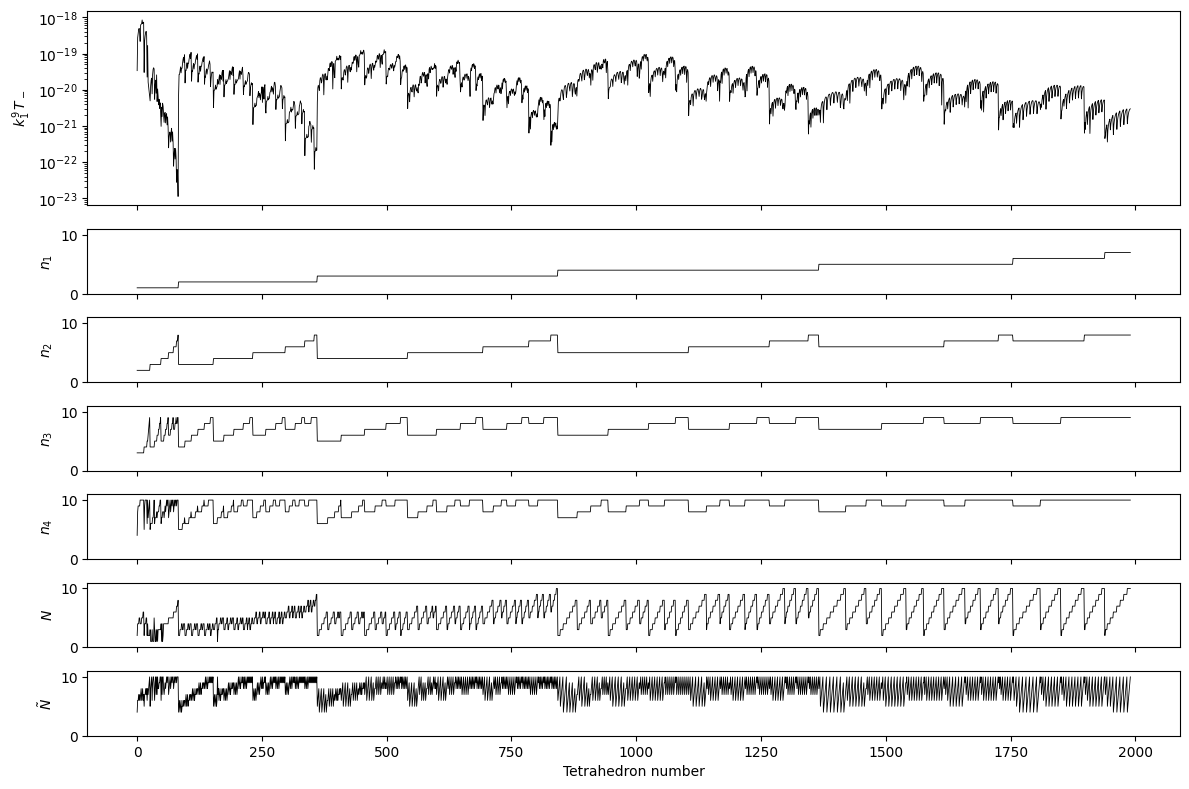

In [9]:
# Fig. 2 reproduction: k1^9 T_- (top) + the binning scheme (lower six panels)
k1 = kc[tetra[:, 0]]
y = np.abs(k1**9 * T_minus)

fig, ax = plt.subplots(7, 1, figsize=(12, 8), sharex=True,
                       gridspec_kw=dict(height_ratios=[3]+[1]*6))
ax[0].semilogy(y, lw=0.6, color='k')

ax[0].set_ylabel(r"$k_1^9\,T_-$")
#ax[0].set_ylim(1e-22, 2e-18)

labels = [r"$n_1$", r"$n_2$", r"$n_3$", r"$n_4$", r"$N$", r"$\tilde N$"]
cols   = [kc[tetra[:, 0]], kc[tetra[:, 1]], kc[tetra[:, 2]], kc[tetra[:, 3]],
          Kc[tetra[:, 4]], Kc[tetra[:, 5]]]
for a, lab, c in zip(ax[1:], labels, cols):
    a.plot(c/kf, lw=0.6, color='k')
    a.set_ylabel(lab); a.set_ylim(0, 11)
ax[-1].set_xlabel("Tetrahedron number")
fig.tight_layout()

## Measure

In [10]:
# ---------------------------------------------------------------------------
# Test bed: Gaussian field with a PURE POWER LAW  P(k) = 2 pi^2 As k^-3.
#
# ---------------------------------------------------------------------------
RES_PV = 64
k_f_pv = 2*np.pi/BOXSIZE
AS_PL  = 1.0                                     # P(k) = 2 pi^2 * AS_PL * k^-3

base_pv = PolyBin3D(boxsize=BOXSIZE, gridsize=RES_PV, Pk=None, pixel_window='none',
                    backend='fftw', sightline='global', real_fft=True)

Pk_pl = lambda k: 2*np.pi**2 * AS_PL * np.asarray(k, float)**-3.0

# tabulate past the grid corner (|k|_max = sqrt(3) k_Nyq) so generate_data never extrapolates
_k_tab = np.geomspace(0.5*k_f_pv, 2.0*np.sqrt(3)*np.pi*RES_PV/BOXSIZE, 2048)
Pk_input_pl = [_k_tab, Pk_pl(_k_tab)]

def gaussian_field(seed):
    """GRF realization with P(k) = 2 pi^2 AS_PL k^-3."""
    return np.asarray(base_pv.generate_data(seed=seed, Pk_input=Pk_input_pl,
                                            output_type='real'), dtype=np.float64)

k_f_pv = 2*np.pi/1000.0

bins_pv = np.linspace(k_f_pv, 11*k_f_pv, 7)         # 10 side bins,  width k_F = 0.00628
# K = |k1+k2| reaches 2*k_max, so the diagonal grid must span twice the side range or the
# upper half of the quadruplets falls outside every diagonal bin and is silently dropped.
# (K < k_f_pv is left unbinned, as before.)
diag_pv = np.linspace(2*k_f_pv, 2*bins_pv[-1], 4)      # 5 diagonal bins, width 0.02639
ts_pv = tspec.TSpec(base_pv, k_bins=bins_pv, diag_bins=diag_pv, shapes=[])
_dist = sum(len(set(sh)) == 4 for sh in ts_pv.shapes_odd)
print("n_k %d  n_diag %d  shapes_odd %d  (4-distinct %d)  cells %d  signal cells %d"
      % (ts_pv.n_k, ts_pv.n_diag, len(ts_pv.shapes_odd), _dist,
         len(ts_pv.shapes_odd)*ts_pv.n_diag, _dist*ts_pv.n_diag))



d0 = gaussian_field(300000)
_dk = base_pv.to_fourier(d0)
_N, _V = base_pv.gridsize.prod(), base_pv.volume
print("\nfield std %.4f   (expect sqrt(As ln(k_Ny/k_F)) = %.4f)"
      % (d0.std(), np.sqrt(AS_PL*np.log(np.pi*RES_PV/BOXSIZE/k_f_pv))))
print("  k        Phat/P_input")
for b in range(ts_pv.n_k):
    m = (base_pv.modk_grid >= bins_pv[b]) & (base_pv.modk_grid < bins_pv[b+1])
    Phat = np.abs(_dk[m])**2 .mean() * _V/_N**2 if False else (np.abs(_dk[m])**2).mean()*_V/_N**2
    kc_b = 0.5*(bins_pv[b] + bins_pv[b+1])
    print("  %.4f   %.4f" % (kc_b, Phat/Pk_pl(kc_b)))

# injection amplitude: g such that the odd piece is ~10% of the field in rms
_, fr0 = tspec.TSpec.make_parity_odd_ic(base_pv, d0, 1.0)
r1 = fr0.std()/d0.std()
g_use = 0.1/r1
print("\nstd(fr)/std(delta) = %.4e  ->  g_use = %.4e" % (r1, g_use))


# Dimensions: [1.00e+03, 1.00e+03, 1.00e+03] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [64, 64, 64]
# Fundamental frequency: [0.0063, 0.0063, 0.0063] h/Mpc
# Nyquist frequency: [0.201, 0.201, 0.201] h/Mpc
# Pixel window: none
# Using FFTW backend
n_k 6  n_diag 3  shapes_odd 120  (4-distinct 45)  cells 360  signal cells 135

field std 2.0769   (expect sqrt(As ln(k_Ny/k_F)) = 1.8616)
  k        Phat/P_input
  0.0115   1.8332
  0.0220   0.9571
  0.0325   1.0341
  0.0429   1.0511
  0.0534   1.0526
  0.0639   1.1438

std(fr)/std(delta) = 5.4367e+00  ->  g_use = 1.8393e-02


In [11]:
bins_pv

array([0.00628319, 0.01675516, 0.02722714, 0.03769911, 0.04817109,
       0.05864306, 0.06911504])

In [12]:
diag_pv

array([0.01256637, 0.05445427, 0.09634217, 0.13823008])

In [13]:
dj = DiscoDJ(dim=3, res=RES, name='tspec_val', device=DEVICE, precision='single', boxsize=BOXSIZE, cosmo=dict(Omega_c=Oc, Omega_b=Ob, h=h, n_s=ns, sigma8=s8))
dj = dj.with_timetables().with_linear_ps(transfer_function='Eisenstein-Hu')
wnf = dj.get_ngenic_noise(seed=42)
dj  = dj.with_ics(white_noise_space='real', white_noise_field=wnf, convert_to_numpy=True)
dj  = dj.with_lpt(n_order=2, convert_to_numpy=True)
X, _, _ = dj.run_nbody(a_ini=0.02, a_end=1.0, n_steps=10, res_pm=2*RES,
                        time_var='D', stepper='bullfrog', method='pm', antialias=0,
                        grad_kernel_order=4, laplace_kernel_order=0, nlpt_order_ics=2,
                        n_resample=1, deconvolve=False, return_displacement=False,
                        chunk_size=None, convert_to_numpy=True)
delta = np.asarray(dj.get_delta_from_pos(X, res=RES, worder=2,
                                        deconvolve=False, antialias=False), dtype=np.float64)


In [14]:
base = PolyBin3D(boxsize = BOXSIZE, gridsize= RES, Pk = None, pixel_window = 'none', backend = 'jax', sightline = 'global', real_fft = True)



# Dimensions: [1.00e+03, 1.00e+03, 1.00e+03] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [64, 64, 64]
# Fundamental frequency: [0.0063, 0.0063, 0.0063] h/Mpc
# Nyquist frequency: [0.201, 0.201, 0.201] h/Mpc
# Pixel window: none
# Using JAX backend


In [15]:
bin_coarse = np.linspace(k_f, 0.2, 8)


In [16]:
ts = tspec.TSpec(base, k_bins = bin_coarse, diag_bins=bin_coarse, shapes = [])


In [17]:
def run_one_sims(dj, n, RES):
    wnf = dj.get_ngenic_noise(seed=300000 + n)
    dj  = dj.with_ics(white_noise_space='real', white_noise_field=wnf, convert_to_numpy=True)
    dj  = dj.with_lpt(n_order=2, convert_to_numpy=True)
    X, _, _ = dj.run_nbody(a_ini=0.02, a_end=1.0, n_steps=10, res_pm=2*RES,
                            time_var='D', stepper='bullfrog', method='pm', antialias=0,
                            grad_kernel_order=4, laplace_kernel_order=0, nlpt_order_ics=2,
                            n_resample=1, deconvolve=False, return_displacement=False,
                            chunk_size=None, convert_to_numpy=True)
    delta = np.asarray(dj.get_delta_from_pos(X, res=RES, worder=2,
                                            deconvolve=False, antialias=False), dtype=np.float64)
    return delta

In [18]:
def make_parity_odd_ic(base, delta_g, g):
        """delta_PV = delta_G + g*(v1 x v2).v3, v_n^a = IFFT[i k^a |k|^-n delta(k)], n =2,1,0"""

        dk = base.to_fourier(delta_g)
        modk = np.where(base.modk_grid == 0, 1.0, base.modk_grid)
        k_comps = [
            base.k_arrs[0][:,None, None], #k_x
            base.k_arrs[1][None, :, None], #k_y
            base.k_arrs[2][None, None, :], #k_z
        ]
        v = [[base.to_real(1j * kc * modk**(-n) *dk) for kc in k_comps] for n in (2,1,0)]
        v1, v2, v3 = v
        prod = base.map_utils.prod_real
        cross=  [
            prod(v1[1], v2[2]) - prod(v1[2], v2[1]), # x
            prod(v1[2], v2[0]) - prod(v1[0], v2[2]), # y
            prod(v1[0], v2[1]) - prod(v1[1], v2[0]), # z
        ]
        fr123 = cross[0]*v3[0] + cross[1]*v3[1] + cross[2]*v3[2]
        return delta_g + g*fr123, fr123  #parity-odd IC, parity-odd piece

In [19]:
def evolve_pv(dj_pv, delta_ic, tag, res=None):
    """Evolve a field with an injected initial condition 
    """
    res = RES_PV if res is None else int(res)
    dj_pv = dj_pv.with_external_ics(delta=np.asarray(delta_ic))
    dj_pv = dj_pv.with_lpt(n_order=2, convert_to_numpy=True)
    X_pv, _, _ = dj_pv.run_nbody(a_ini=0.02, a_end=1.0, n_steps=10, res_pm=2*res,
                            time_var='D', stepper='bullfrog', method='pm', antialias=0,
                            grad_kernel_order=4, laplace_kernel_order=0, nlpt_order_ics=2,
                            n_resample=1, deconvolve=False, return_displacement=False,
                            chunk_size=None, convert_to_numpy=True)
    delta = np.asarray(dj_pv.get_delta_from_pos(X_pv, res=res, worder=2,
                                            deconvolve=False, antialias=False), dtype=np.float64)
    return delta


In [20]:
def run_one_sim_pv(dj, n, res, g, seed0=300000, base_obj=None):
    """inject the parity-odd piece on the linear density field.

    Returns evolved delta_p, delta_m (a = 1) and the IC fields ic_p, ic_m, all float64.
    """
    res = RES_PV if res is None else int(res)
    base_obj = base_pv if base_obj is None else base_obj
    assert (np.asarray(base_obj.gridsize) == res).all(), \
        "res=%d does not match base_obj.gridsize=%s" % (res, base_obj.gridsize)
    wnf  = dj.get_ngenic_noise(seed=seed0 + n)
    dj_l = dj.with_ics(white_noise_space='real', white_noise_field=wnf, convert_to_numpy=True)
    d_lin = np.asarray(dj_l.delta_ini, dtype=np.float64)      # linear density, carries P_lin

    _, fr = make_parity_odd_ic(base_obj, d_lin, 1.0)          # cubic in d_lin -> n_P != 0
    fr = np.asarray(fr, dtype=np.float64)
    ic_p = d_lin + g*fr
    ic_m = d_lin - g*fr

    delta_p = evolve_pv(dj, ic_p, "p", res=res)
    delta_m = evolve_pv(dj, ic_m, "m", res=res)
    return delta_p, delta_m, ic_p, ic_m


In [21]:

import time
_t = time.time()
N_odd = ts_pv.mode_counts_odd()
good = N_odd > 1e-6*N_odd.max()
print("N_odd in %.0f s   supported bins %d/%d" % (time.time()-_t, good.sum(), good.size))


CONV = ts_pv._discrete_to_continuum_odd()                  # = V^3 / N^4
print("V^3/N^4 = %.4e     N^4/V^3 = %.4e  <- predicted raw-ratio/tau_- if the theory is right"
      % (CONV, 1.0/CONV))

N_odd in 10 s   supported bins 212/360
V^3/N^4 = 2.1176e+05     N^4/V^3 = 4.7224e-06  <- predicted raw-ratio/tau_- if the theory is right


In [22]:

N_sims = 30
acc = []
for n in range(N_sims):
    if n % 5 == 0:
        print("  sim %d/%d" % (n, N_sims), flush=True)
    d = gaussian_field(300000 + n)
    _, frn = tspec.TSpec.make_parity_odd_ic(base_pv, d, 1.0)
    tp = ts_pv.Tk_odd_numerator(d + g_use*frn)
    tm = ts_pv.Tk_odd_numerator(d - g_use*frn)
    acc.append(0.5*(tp - tm))
acc = np.array(acc)

_Ns = np.where(good, N_odd, 1.0)
tau_hat = np.where(good, acc.mean(0)/_Ns * CONV, np.nan)
tau_err = np.where(good, acc.std(0, ddof=1)/np.sqrt(N_sims)/_Ns * CONV, np.nan)
print("measured %d supported bins over %d sims" % (good.sum(), N_sims))
print("median |tau_hat| = %.4e   median per-bin |z| = %.2f"
      % (np.nanmedian(np.abs(tau_hat)), np.nanmedian(np.abs(tau_hat/tau_err))))

  sim 0/30
  sim 5/30
  sim 10/30
  sim 15/30
  sim 20/30
  sim 25/30
measured 212 supported bins over 30 sims
median |tau_hat| = 6.2717e+18   median per-bin |z| = 0.76


## Bin-average for the thin bin prediction 

$$\langle \tau_{-} \rangle = \dfrac{\sum_{cell} G^2 \, \tau_{-}(k_1, k_2, k_3, k_4)}{\sum_{cell} G^2}$$

where $G = (k_1 \times k_2). k_3$

In [23]:

# SAMPLING.  Per shape, draw n1, n2, n3 uniformly from the three shell lists, set
# n4 = -(n1+n2+n3), accept when |n4| lands in shell s4 and k_F|n1+n2| in a diagonal bin.
# (n1,n2,n3) -> quadruplet is a bijection onto the cell, so uniform sampling makes every
# accepted quadruplet equally likely and the plain weighted ratio is the estimator.  
# One draw lands in exactly one B, so a single pass over a shape fills all
# of its diagonal bins at once.
#
# Shell edges are half-open [lo, hi) to match map_utils.fourier_filter (modk >= kmin,
# modk < kmax) -- that is what makes this the SAME quadruplet set the estimator sums.
# Shells are built on the unbounded integer lattice, so the answer depends only on
# n = k/k_F and is universal for a given binning.  Exact while every bin edge stays inside
# the Nyquist sphere; above it the grid holds only the corners of the shell and this
# over-counts (diag_pv currently runs past k_Ny -- see the print below).


def shell_vectors(ts, nmax=None):
    """Integer vectors n with k_F|n| in [k_bins[b], k_bins[b+1]), one array per side bin."""
    kF = np.asarray(ts.base.kF, dtype=float)
    assert np.allclose(kF, kF[0]), "cubic box assumed"
    kF = float(kF[0])
    if nmax is None:
        # every component obeys |n_i| <= |n| <= k_bins[-1]/kF, so this cube contains every
        # shell vector; +1 is slack against the ceil landing on a lattice point
        nmax = int(np.ceil(ts.k_bins[-1]/kF)) + 1
    r = np.arange(-nmax, nmax + 1)
    X, Y, Z = np.meshgrid(r, r, r, indexing='ij')
    modn = np.sqrt(X*X + Y*Y + Z*Z).ravel()*kF          # physical |k| of every lattice point
    n_all = np.stack([X.ravel(), Y.ravel(), Z.ravel()], 1).astype(np.int64)
    # half-open [lo, hi): same test as map_utils.fourier_filter, so this is the estimator's
    # own shell membership, not an approximation to it
    return [n_all[(modn >= ts.k_bins[b]) & (modn < ts.k_bins[b+1])]
            for b in range(ts.n_k)], kF


def binned_odd_average(ts, f, n_samples=int(1e6), seed=0, chunk=int(2e6), nmax=None,
                       verbose=False):
    """G^2-weighted lattice bin average of f over every (odd shape, diagonal bin) cell.

    f          callable taking k of shape (4, n) -- MAGNITUDES in physical units, slot
               order matching ts.shapes_odd -- returning shape (n,).
    n_samples  TOTAL budget, split evenly across shapes.

    Returns (val, relerr, weight), each (len(ts.shapes_odd), ts.n_diag):
      val     the average above; NaN where nothing was accepted
      relerr  ratio-estimator standard error / |val|.  G^2*f is heavy-tailed, so this runs
              ~2x optimistic -- a usability cut, not a sigma.
      weight  raw SUM_accepted G^2 in k_F^6 units (G is built from the INTEGER vectors),
              unnormalized -- it grows with the per-shape budget and acceptance rate.  Not
              comparable to mode_counts_odd, which carries physical k, a 1/N^3, and the
              pair-swap fold ((ij) vs (kl)); all three cancel in the ratio here.  Use it
              only as a hit counter.
    """
    shells, kF = shell_vectors(ts, nmax=nmax)
    n_shapes = len(ts.shapes_odd)
    # flat budget per shape: acceptance rates differ by orders of magnitude between shapes,
    # so relerr is very uneven across the output -- that is what the mc_ok cut downstream is for
    per_shape = max(1, int(n_samples)//max(1, n_shapes))
    shp = (n_shapes, ts.n_diag)

    # Ratio-estimator accumulators.  S* carry weight G^2; T* carry G^4

    S0, S1 = np.zeros(shp), np.zeros(shp)                    # sum G^2, sum G^2 f  -> the estimate
    T0, T1, T2 = np.zeros(shp), np.zeros(shp), np.zeros(shp)  # sum G^4 {1, f, f^2} -> variance only

    rng = np.random.default_rng(seed)
    for si, (b1, b2, b3, b4) in enumerate(ts.shapes_odd):
        A, B_, C = shells[b1], shells[b2], shells[b3]
        if min(len(A), len(B_), len(C), len(shells[b4])) == 0:
            continue                                    # an empty shell -> cell is unreachable
        if verbose and si % 200 == 0:
            print("    shape %d/%d" % (si, n_shapes), flush=True)
        drawn = 0
        while drawn < per_shape:
            c = min(chunk, per_shape - drawn)
            drawn += c    # counts proposals, and must stay above the `continue`s below --
                          # counting accepts instead never terminates on a low-acceptance shape
            n1 = A[rng.integers(len(A), size=c)]         # uniform over shell b1
            n2 = B_[rng.integers(len(B_), size=c)]       # uniform over shell b2
            n3 = C[rng.integers(len(C), size=c)]         # uniform over shell b3
            n4 = -(n1 + n2 + n3)   # closes sum k = 0 exactly; that is why only 3 shells are sampled

            r4 = np.sqrt((n4*n4).sum(1))*kF
            ok = (r4 >= ts.k_bins[b4]) & (r4 < ts.k_bins[b4+1])   # [lo, hi), leg 4 must land in shell b4
            if not ok.any():
                continue
            n12 = n1 + n2
            K = np.sqrt((n12*n12).sum(1))*kF            # internal diagonal |k1+k2|

            # searchsorted 'right' - 1 is the same [lo, hi) rule: -1 below the first edge,
            # n_diag at/above the last edge -- both rejected on the next line
            Bd = np.searchsorted(ts.diag_bins, K, side='right') - 1
            ok &= (Bd >= 0) & (Bd < ts.n_diag)
            if not ok.any():
                continue

            # n4 deliberately not re-masked -- only its magnitude r4 is needed downstream
            n1, n2, n3, Bd, r4 = n1[ok], n2[ok], n3[ok], Bd[ok], r4[ok]

            # G in integer units; physical G is kF^3 * G, so the kF^6 in w cancels in S1/S0.
            # This is what makes the average depend only on n = k/k_F (header's universality claim).
            G = np.einsum('ij,ij->i', np.cross(n1, n2), n3).astype(float)
            w = G*G
            k = np.stack([np.sqrt((n1*n1).sum(1))*kF, np.sqrt((n2*n2).sum(1))*kF,
                          np.sqrt((n3*n3).sum(1))*kF, r4])   # physical magnitudes, slot order = shape
            v = np.asarray(f(k), dtype=float)

            # one pass fills every diagonal bin of this shape: each draw carries its own Bd
            nd = ts.n_diag
            S0[si] += np.bincount(Bd, weights=w,       minlength=nd)
            S1[si] += np.bincount(Bd, weights=w*v,     minlength=nd)
            T0[si] += np.bincount(Bd, weights=w*w,     minlength=nd)
            T1[si] += np.bincount(Bd, weights=w*w*v,   minlength=nd)
            T2[si] += np.bincount(Bd, weights=w*w*v*v, minlength=nd)

    hit = S0 > 0                                     # cell got at least one accepted quadruplet
    den = np.where(hit, S0, 1.0)                     # dummy 1.0 only to keep the divide quiet
    val = np.where(hit, S1/den, np.nan)
    m = np.where(hit, S1/den, 0.0)                   # same as val, NaN-free for the variance below
    # T2 - 2m T1 + m^2 T0 is sum w^2 (f - m)^2 expanded; maximum(...,0) guards the
    # catastrophic cancellation when f is nearly constant across the cell
    var = np.maximum(T2 - 2*m*T1 + m*m*T0, 0.0)/den**2      # sum w^2 (f-mean)^2 / (sum w)^2
    relerr = np.where(hit & (val != 0),
                      np.sqrt(var)/np.abs(np.where(val != 0, val, 1.0)), np.inf)
    return val, relerr, np.where(hit, S0, 0.0)


# --- GATE 1: f -> 1 must return exactly 1.0 wherever anything was accepted --------------
# Tests the whole ratio machinery (weights, bincount, cell assignment) with the answer
# known analytically.  A failure here means the average is wrong for every f.
_v1, _r1, _w1 = binned_odd_average(ts_pv, lambda km: np.ones(km.shape[1]),
                                   n_samples=int(2e6), seed=1)
_h = _w1 > 0
print("GATE f->1 : %d/%d cells hit, max|val-1| = %.2e   (~ 0 is expected)"
      % (_h.sum(), _h.size, np.abs(_v1[_h] - 1).max()))

# --- Nyquist check: shells above k_Ny exist on the integer lattice but not on the grid ---
_kNy = float(np.min(base_pv.kNy))
print("k_Ny = %.4f   side bins above it: %d/%d   diagonal bins above it: %d/%d"
      % (_kNy, int((bins_pv[1:] > _kNy).sum()), ts_pv.n_k,
         int((diag_pv[1:] > _kNy).sum()), ts_pv.n_diag))


GATE f->1 : 220/360 cells hit, max|val-1| = 0.00e+00   (~ 0 is expected)
k_Ny = 0.2011   side bins above it: 0/6   diagonal bins above it: 0/3


In [24]:
# ---------------------------------------------------------------------------
# BINNED parity-odd theory -- replaces tau_-(k_cen) everywhere below.

# ---------------------------------------------------------------------------
N_MC = int(6e8)
# The MC result depends only on n = k/k_F, so it is universal across BOXSIZE/RES -- but that
# makes it a function of the EDGE SET in k_F units, which (n_k, n_diag) does not capture.
# Keying on the counts alone silently reloads a cache built on different edges; tau_- ~ k^-12,
# so a 2x shift in the edges is a ~1e3 error in the theory line.  Hash the edges.
_mc_key = hashlib.md5(np.ascontiguousarray(ts_pv.k_bins, float).tobytes()
                    + np.ascontiguousarray(ts_pv.diag_bins, float).tobytes()).hexdigest()[:10]
MC_CACHE = 'tau_binned_nk%d_nd%d_%s.npz' % (ts_pv.n_k, ts_pv.n_diag, _mc_key)

if os.path.exists(MC_CACHE):
    _z = np.load(MC_CACHE)
    tau_binned, tau_mc_rel, _mc_w = _z['val'], _z['rel'], _z['w']
    print("loaded %s" % MC_CACHE)
else:
    tau_binned, tau_mc_rel, _mc_w = binned_odd_average(
        ts_pv, lambda km: tau_minus(km, g_use, As=AS_PL), n_samples=N_MC, seed=0,
        verbose=True)
    np.savez(MC_CACHE, val=tau_binned, rel=tau_mc_rel, w=_mc_w)
    print("saved %s" % MC_CACHE)

# MC convergence cut.  relerr is the ratio-estimator standard error; G^2*tau_- is
# heavy-tailed so it runs ~2x optimistic -- treat this as a usability cut, not a sigma.
mc_ok = (_mc_w > 0) & np.isfinite(tau_binned) & (tau_mc_rel < 0.05)
print("MC-converged cells (relerr < 5%%): %d / %d" % (mc_ok.sum(), mc_ok.size))

# How big is the correction the old comparison was missing?
_kc = 0.5*(bins_pv[:-1] + bins_pv[1:])
tau_cen2d = np.repeat(
    np.array([tau_minus(_kc[list(s)], g_use, As=AS_PL) for s in ts_pv.shapes_odd])[:, None],
    ts_pv.n_diag, 1)
_d4 = np.array([len(set(s)) == 4 for s in ts_pv.shapes_odd])[:, None]
_c = np.where(mc_ok & _d4 & (tau_cen2d != 0), tau_binned/tau_cen2d, np.nan)
_n1 = np.array([s[0] for s in ts_pv.shapes_odd])[:, None] + 0*tau_binned
print("\nbinned <tau_->_{G^2} / tau_-(k_cen) ")
print(" n1  dk/k     N   median      16-84%")
for _i in range(ts_pv.n_k):
    _m = np.isfinite(_c) & (_n1 == _i)
    if _m.sum() > 3:
        print("  %2d  %.2f  %4d  %+.4f   [%+.4f, %+.4f]"
              % (_i+1, 1.0/(_i+1), _m.sum(), np.nanmedian(_c[_m]),
                 *np.nanpercentile(_c[_m], [16, 84])))



loaded tau_binned_nk6_nd3_e2e86e649b.npz
MC-converged cells (relerr < 5%): 158 / 360

binned <tau_->_{G^2} / tau_-(k_cen) 
 n1  dk/k     N   median      16-84%
   1  1.00    48  +0.9089   [+0.2721, +1.1877]
   2  0.50    24  +0.8549   [+0.6043, +0.9202]
   3  0.33     7  +0.9881   [+0.8062, +1.0505]


/tmp/ipykernel_518035/2335052525.py:36: RuntimeWarning: divide by zero encountered in divide
  _c = np.where(mc_ok & _d4 & (tau_cen2d != 0), tau_binned/tau_cen2d, np.nan)


## Exact lattice bin average of $\tau_-$ by FFT factorisation

Both theory columns above are still **approximations** to what the estimator returns.  Section 1.4
of `docs/trispectrum_binned_theory.md` shows the estimator returns, exactly,

$$\langle\hat\tau[s,B]\rangle \;=\; \frac{\sum_{\rm Cell} G^2\,\tau_-}{\sum_{\rm Cell} G^2}
\;\equiv\; \langle\tau_-\rangle_{G^2,\,\rm Cell},\qquad G=\mathbf k_1\cdot(\mathbf k_2\times\mathbf k_3)$$

a ratio of two **lattice** sums.  `tau_minus(k_cen)` is its thin-bin limit; `binned_odd_average`
above is a Monte-Carlo *estimate* of it, with a heavy-tailed weight and a ~2x optimistic error bar.
This section computes the same object **exactly and deterministically**.

$\tau_-$ is **separable** in the four side magnitudes -- it is the alternant $\det[k_i^{E_j}]$,
$E=(-5,-4,-3,0)$, i.e. a signed sum of products $k_1^ak_2^bk_3^ck_4^d$ -- and so is $G^2$.  So the
lattice sum is the *same* FFT contraction `mode_counts_odd` already performs, with
$\delta^{\rm FFT}(k)\to|k|^p$:

$$T_{b,p}^{cd}(\mathbf x)={\rm IFFT}[W_b(k)\,k^ck^d|k|^p],\qquad O_{b,p}(\mathbf x)={\rm IFFT}[W_b(k)|k|^p]$$
$$L_{12}^{ab}=\epsilon_{acd}\epsilon_{bef}T_{b_1p_1}^{ce}T_{b_2p_2}^{df},\qquad
\bar L_{12}^{ab}={\rm IFFT}\big[W_B(K)\,{\rm FFT}[L_{12}^{ab}]\big],\qquad
R_{34}^{ab}=T_{b_3p_3}^{ab}O_{b_4p_4}$$
$$C_b(p_a)=\sum_{\mathbf x}\sum_{ab}\bar L_{12}^{ab}(\mathbf x)\,R_{34}^{ab}(\mathbf x),
\qquad\text{and}\qquad \texttt{mode\_counts\_odd()}=C_b(0,0,0,0).$$

The 24 permutations of the alternant collapse to **6 contractions**: grouping $S_4$ by which
unordered exponent pair lands on legs $\{1,2\}$, the sign factorises as
$\mathrm{sgn}(p_0)\,\mathrm{sgn}(\tau_{12})\,\mathrm{sgn}(\tau_{34})$ and each group of four becomes
one contraction of antisymmetrised maps.  


In [25]:
# ---------------------------------------------------------------------------
# EXACT LATTICE BIN AVERAGE of tau_- by FFT factorisation.

EXPS_TAU = (-5.0, -4.0, -3.0, 0.0)          # (n_P-2, n_P-1, n_P, 0) at n_P = -3

# ({E_a,E_b} -> legs 1,2 | {E_c,E_d} -> legs 3,4), with sign(p0) of the base permutation.
# sign(p0) = inversion parity of (leg -> exponent index): 0,1,2,2,3,4 inversions here.
TAU_SPLITS = [((0, 1), (2, 3), +1),
              ((0, 2), (1, 3), -1),
              ((0, 3), (1, 2), +1),
              ((1, 2), (0, 3), +1),
              ((1, 3), (0, 2), -1),
              ((2, 3), (0, 1), +1)]

IDX6 = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]   # symmetric (a,b), 6 of 9
W6   = [1.0, 1.0, 1.0, 2.0, 2.0, 2.0]                     # off-diagonals counted twice


def _kpow_grid(ts, p, kf):
    """(|k|/k_F)^p on the rfft grid.  The origin must be guarded BEFORE the shell filter:
    |k|^-5 there is inf, and inf*0 = nan, which would poison every map.  p = 0 never hits
    this, so mode_counts_odd has no equivalent guard."""
    modk = np.asarray(ts.base.modk_grid)
    return (np.where(modk == 0, 1.0, modk)/kf)**p


def tensor_shell_maps_p(ts, p, kf):
    """T_{b,p}^{cd}(x) = IFFT[ W_b(k) k^c k^d (|k|/k_F)^p ].  p=0 reproduces
    TSpec._tensor_shell_maps exactly.  Full k (not k-hat), matching the i k^a legs."""
    w = _kpow_grid(ts, p, kf) * (ts.base.complex_zeros() + 1.0)
    kcm = [ts.base.k_arrs[0][:, None, None],
           ts.base.k_arrs[1][None, :, None],
           ts.base.k_arrs[2][None, None, :]]
    T = []
    for b in range(ts.n_k):
        Tb = [[None]*3 for _ in range(3)]
        for c in range(3):
            for d in range(c, 3):
                Tb[c][d] = Tb[d][c] = ts.base.to_real(ts.base.map_utils.fourier_filter(
                    kcm[c]*kcm[d]*w, 0, ts.k_bins[b], ts.k_bins[b+1]))
        T.append(Tb)
    return T


def unit_shell_maps_p(ts, p, kf):
    """O_{b,p}(x) = IFFT[ W_b(k) (|k|/k_F)^p ].  p=0 is TSpec._unit_shell_maps."""
    w = _kpow_grid(ts, p, kf) * (ts.base.complex_zeros() + 1.0)
    return [ts.base.to_real(ts.base.map_utils.fourier_filter(
        w, 0, ts.k_bins[b], ts.k_bins[b+1])) for b in range(ts.n_k)]


def left_pairs_p(ts, pairs, Ta, Tb, anti=True):
    """L^{ab}(i,j) = eps_acd eps_bef Ta[i]^{ce} Tb[j]^{df}, the legs-1,2 half of G^2.
    anti=True returns L(Ta,Tb) - L(Tb,Ta) with the subtraction done term by term, so the
    antisymmetrisation costs no extra peak memory.  anti=False with Ta=Tb is exactly the
    M block of TSpec.mode_counts_odd."""
    prod = ts.base.map_utils.prod_real
    eps_a = {}
    for (a, c, d, s) in ts._EPS:
        eps_a.setdefault(a, []).append((c, d, s))
    out = []
    for (i, j) in pairs:
        comp = []
        for (a, b) in IDX6:
            acc = None
            for (c, d, s1) in eps_a[a]:
                for (e, f, s2) in eps_a[b]:
                    core = prod(Ta[i][c][e], Tb[j][d][f])
                    if anti:
                        core = core - prod(Tb[i][c][e], Ta[j][d][f])
                    t = s1*s2*core
                    acc = t if acc is None else acc + t
            comp.append(acc)
        out.append(comp)
    return out


def right_pairs_p(ts, pairs, Tc, Td, Oc, Od, anti=True):
    """R^{ab}(k,l) = Tc[k]^{ab} Od[l], the legs-3,4 half.  Leg 3 is the vector leg and
    leg 4 the scalar one, so the two are NOT interchangeable and the antisymmetrisation
    over their exponents is a genuine difference of two distinct map products."""
    prod = ts.base.map_utils.prod_real
    out = []
    for (k, l) in pairs:
        comp = []
        for (a, b) in IDX6:
            m = prod(Tc[k][a][b], Od[l])
            if anti:
                m = m - prod(Td[k][a][b], Oc[l])
            comp.append(m)
        out.append(comp)
    return out


def lattice_tau_numerator(ts, kf, exps=EXPS_TAU, verbose=True):
    """SUM_Cell G^2 * det[(k_i/k_F)^{E_j}], on the lattice, exactly.

    Returns (num, mag, T, O).  `mag` accumulates |contraction| per split -- |num|/mag is
    the surviving fraction after the 6-way cancellation, i.e. how many digits are left.
    T and O are handed back so GATE 1 can reuse the p=0 maps without rebuilding them.
    """
    import time
    pairs, rows, cols = ts._odd_pair_index()
    T = [tensor_shell_maps_p(ts, e, kf) for e in exps]
    O = [unit_shell_maps_p(ts, e, kf) for e in exps]
    num = np.zeros((len(ts.shapes_odd), ts.n_diag))
    mag = np.zeros_like(num)
    for (ia, ib), (ic, idd), sgn in TAU_SPLITS:
        _t = time.time()
        M = left_pairs_p(ts, pairs, T[ia], T[ib], anti=True)
        S = right_pairs_p(ts, pairs, T[ic], T[idd], O[ic], O[idd], anti=True)
        c = ts._pair_contract(M, S, rows, cols, weights=W6)   # consumes M in place
        num += sgn*c
        mag += np.abs(c)
        del M, S
        if verbose:
            print("   split (E%d,E%d | E%d,E%d) sign %+d   %.0f s"
                  % (ia, ib, ic, idd, sgn, time.time()-_t), flush=True)
    return num, mag, T, O

In [26]:
# ---------------------------------------------------------------------------
# RUN the lattice bin average.
#
# tau_lat is the EXACT G^2-weighted bin average of Eq. 45 over Cell(s,B),
#     <tau_->_{G^2, Cell} = SUM_Cell G^2 tau_- / SUM_Cell G^2 ,
# computed by the FFT factorisation of cell 29, not sampled.  It depends ONLY on
# (k_bins, diag_bins, RES) -- no field, no seeds, no realisations -- so it is a fixed
# geometric table: compute once, cache to disk, reuse for every g and As.
#
# The aliasing line stays: below RES >= 4 n_k + 3 the real-space product wraps and tau_lat
# is silently wrong -- no downstream fit can see it, it just returns a wrong A.
# ---------------------------------------------------------------------------
import time

kcen_pv  = 0.5*(bins_pv[:-1] + bins_pv[1:])
distinct = np.array([len(set(s)) == 4 for s in ts_pv.shapes_odd])

print("aliasing: RES = %d, need >= 4 n_k + 3 = %d   -> %s"
      % (RES_PV, 4*ts_pv.n_k + 3,
         "OK (contraction exact)" if RES_PV >= 4*ts_pv.n_k + 3 else "ALIASED -- NOT exact"))

# Cache on the EDGES, not the counts: tau_- ~ k^-12, so a shifted edge set is a ~1e3 error
# and (n_k, n_diag) cannot see it.  RES enters too, through the aliasing bound and through
# which modes exist at all.
_lat_key = hashlib.md5(np.ascontiguousarray(ts_pv.k_bins, float).tobytes()
                       + np.ascontiguousarray(ts_pv.diag_bins, float).tobytes()
                       + np.int64(RES_PV).tobytes()).hexdigest()[:10]
LAT_CACHE = 'tau_lattice_nk%d_nd%d_res%d_%s.npz' % (ts_pv.n_k, ts_pv.n_diag, RES_PV, _lat_key)

if os.path.exists(LAT_CACHE):
    _z = np.load(LAT_CACHE)
    num_lat, mag_lat = _z['num'], _z['mag']
    print("loaded %s" % LAT_CACHE)
else:
    _t = time.time()
    # _T, _O are the shell maps; several GB at RES 64, and only the gates used them.
    num_lat, mag_lat, _T, _O = lattice_tau_numerator(ts_pv, k_f_pv)
    del _T, _O
    print("lattice numerator: %.0f s" % (time.time() - _t))
    np.savez(LAT_CACHE, num=num_lat, mag=mag_lat)
    print("saved %s" % LAT_CACHE)

# Physical units.  tau_-(k) = pref * det[k_i^{E_j}] with E = (-5,-4,-3,0) summing to -12,
# so det[k^E] = k_F^-12 det[(k/k_F)^E].  N_odd = SUM_Cell G^2 is the denominator.  Same
# prefactor as tau_minus() -- no free knob.
PREF_TAU = g_use * (2*np.pi**2*AS_PL)**3
tau_lat  = np.where(good, PREF_TAU * k_f_pv**-12 * num_lat/np.where(good, N_odd, 1.0), np.nan)


aliasing: RES = 64, need >= 4 n_k + 3 = 27   -> OK (contraction exact)
loaded tau_lattice_nk6_nd3_res64_cc09b68cd7.npz


In [27]:
# Amplitude fit: measurement vs the BINNED theory from the previous cell.
#
# mc_ok drops cells where the THEORY is not MC-converged -- a noisy theory value biases an
# inverse-variance fit just as a noisy measurement does.

finite = np.isfinite(tau_hat) & np.isfinite(tau_err) & (tau_err > 0)
sel    = good & distinct[:, None] & finite & mc_ok
x, y, ye = tau_binned[sel], tau_hat[sel], tau_err[sel]
assert sel.sum() > 0, "no usable signal bins (good=%d finite=%d)" % (int(good.sum()),
                                                                    int(finite.sum()))

# Inverse-variance best-fit amplitude  meas = A * theory.  A == 1 closes the comparison.
A     = np.sum(x*y/ye**2) / np.sum(x**2/ye**2)
A_err = 1.0/np.sqrt(np.sum(x**2/ye**2))
print("measured vs BINNED tau_minus over %d bins:" % sel.sum())
print("   corr            = %.4f" % np.corrcoef(x, y)[0, 1])
print("   sign agreement  = %.3f" % np.mean(np.sign(x) == np.sign(y)))
print("   best-fit A      = %.4f +- %.4f      (A = 1 => closed)" % (A, A_err))
print("   chi2/dof at A=1 = %.2f" % np.mean(((y - x)/ye)**2))

# Same fit against the OLD bin-centre theory, on the identical cell set, so the change is
# attributable to the theory line alone and to nothing else.
_xc = tau_cen2d[sel]
_Ac = np.sum(_xc*y/ye**2)/np.sum(_xc**2/ye**2)
print("   [bin-centre theory, same cells: A = %.4f +- %.4f]"
      % (_Ac, 1.0/np.sqrt(np.sum(_xc**2/ye**2))))

n1 = np.repeat(np.array([s[0] for s in ts_pv.shapes_odd])[:, None], ts_pv.n_diag, 1)[sel]
print("\n  k1 bin   dk/k1    N     median meas/binned   median meas/bin-centre")
for v in sorted(set(n1.tolist())):
    m = n1 == v
    print("    %d      %.2f   %4d      %+.3f              %+.3f"
          % (v, (bins_pv[v+1]-bins_pv[v])/kcen_pv[v], int(m.sum()),
             np.median(y[m]/x[m]), np.median(y[m]/_xc[m])))


measured vs BINNED tau_minus over 78 bins:
   corr            = 0.9805
   sign agreement  = 0.731
   best-fit A      = 1.0650 +- 0.0317      (A = 1 => closed)
   chi2/dof at A=1 = 1.36
   [bin-centre theory, same cells: A = 0.8444 +- 0.0275]

  k1 bin   dk/k1    N     median meas/binned   median meas/bin-centre
    0      0.91     47      +1.088              +1.028
    1      0.48     24      -1.481              -1.374
    2      0.32      7      +40.848              +36.914


signal bins : mean pull -0.11   rms pull 1.16   (both ~0 and ~1 => closed)
null bins   : mean z    +0.03   rms z    0.94   (theory = 0 there)  [134 bins]


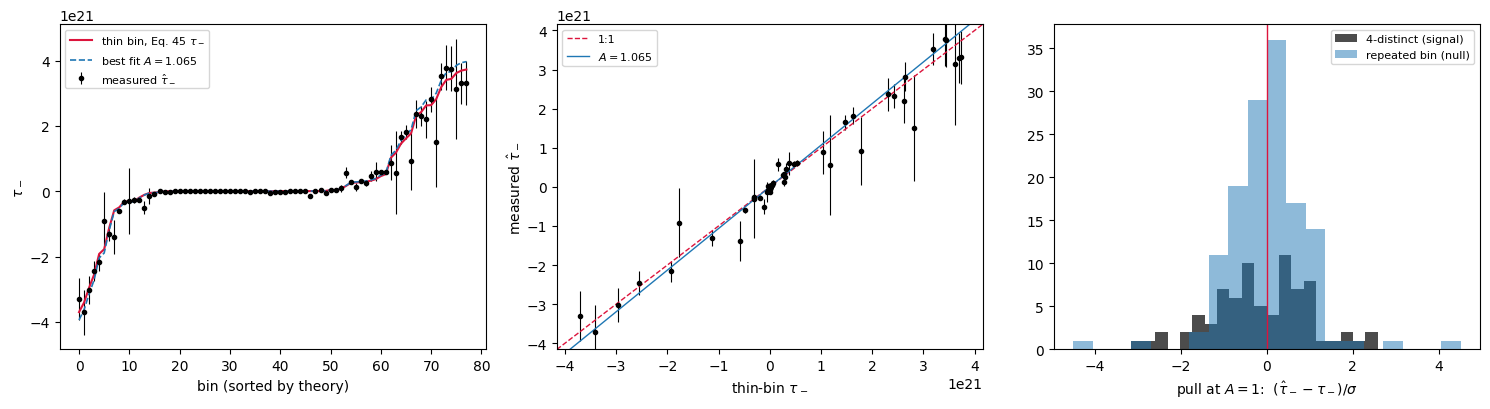

In [28]:
# Measured parity-odd trispectrum vs the thin-bin tau_minus curve.
order = np.argsort(x)
xs, ys, yes = x[order], y[order], ye[order]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) direct comparison, sorted by theory
ax[0].errorbar(np.arange(len(ys)), ys, yerr=yes, fmt='o', ms=3, lw=0.8, color='k',
               label=r'measured $\hat\tau_-$')
ax[0].plot(np.arange(len(xs)), xs, '-', color='crimson', lw=1.5,
           label=r'thin bin, Eq. 45 $\tau_-$')
ax[0].plot(np.arange(len(xs)), A*xs, '--', color='C0', lw=1.2, label='best fit $A=%.3f$' % A)
ax[0].set_xlabel("bin (sorted by theory)"); ax[0].set_ylabel(r"$\tau_-$")
ax[0].legend(fontsize=8)

# (b) scatter -- should sit on 1:1 with no rescaling
lim = np.max(np.abs(np.concatenate([xs, ys])))*1.1
ax[1].errorbar(xs, ys, yerr=yes, fmt='o', ms=3, lw=0.8, color='k')
ax[1].plot([-lim, lim], [-lim, lim], '--', color='crimson', lw=1, label='1:1')
ax[1].plot([-lim, lim], [-A*lim, A*lim], '-', color='C0', lw=1, label='$A=%.3f$' % A)
ax[1].set_xlim(-lim, lim); ax[1].set_ylim(-lim, lim)
ax[1].set_xlabel(r"thin-bin $\tau_-$"); ax[1].set_ylabel(r"measured $\hat\tau_-$")
ax[1].legend(fontsize=8)

# (c) pulls at A = 1, against the repeated-bin shapes where theory is exactly zero.
# `finite` from the previous cell also gates the null channel -- same failure modes there.
pull     = (ys - xs)/yes
nul      = good & ~distinct[:, None] & finite
pull_nul = tau_hat[nul]/tau_err[nul]

ax[2].hist(pull, bins=20, alpha=0.7, color='k', label='4-distinct (signal)')
if pull_nul.size:
    ax[2].hist(pull_nul, bins=20, alpha=0.5, color='C0', label='repeated bin (null)')
ax[2].axvline(0, color='crimson', lw=1)
ax[2].set_xlabel(r"pull at $A=1$:  $(\hat\tau_- - \tau_-)/\sigma$"); ax[2].legend(fontsize=8)

fig.tight_layout()

print("signal bins : mean pull %+.2f   rms pull %.2f   (both ~0 and ~1 => closed)"
      % (pull.mean(), pull.std()))
if pull_nul.size:
    print("null bins   : mean z    %+.2f   rms z    %.2f   (theory = 0 there)  [%d bins]"
          % (pull_nul.mean(), pull_nul.std(), pull_nul.size))
else:
    print("null bins   : none usable")

/tmp/ipykernel_518035/2918243304.py:12: RuntimeWarning: invalid value encountered in sqrt
  G_rms = np.sqrt(N_odd/_Nsc)                                   # units of k^3


tetrahedra plotted: 78   slot convention: k1<k2<k3<k4 (parity applied)
theory sign after parity: min +7.141e+10  (must be > 0)
lattice / MC on the 78 plotted cells: median 0.9994  [16-84%: 0.9958, 1.0041]  max|dev| 1.78e-02
lattice sign after parity: min +7.209e+10  (must be > 0)

negative measured points : 21/78 (27%)
  median |z| negatives   : 0.86   (noise-consistent if <~2)
  median |z| positives   : 2.99
  significantly wrong sign (z < -2 AND theory z > +2): 0

ratio panel: 41/78 cells kept   median meas/MC +1.108   [16-84%: +0.887, +1.555]
             41/78 cells kept   median meas/lattice +1.105   [16-84%: +0.884, +1.559]


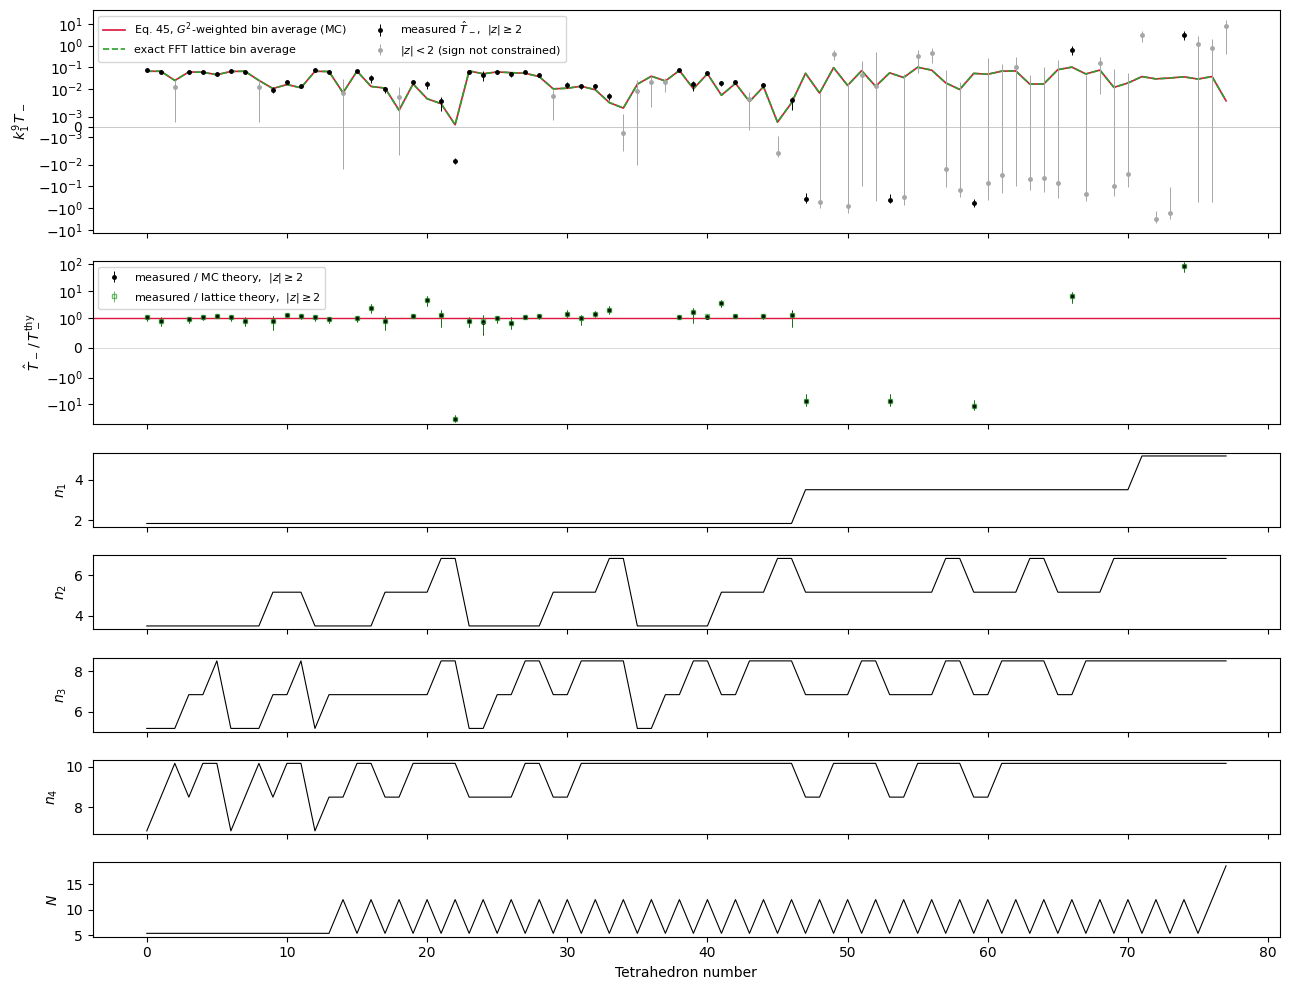

In [29]:
# Measured vs BINNED theory in the Fig. 2 variable k1^9 T_-, plus the measured/theory ratio.
#
# Two theory curves, both G^2-weighted bin averages of the SAME Eq. 45 shape:
#   crimson  tau_binned  Monte-Carlo bin average   (needs mc_ok)
#   green    tau_lat     exact FFT lattice bin average, T_{b,p}^{cd} = IFFT[W_b k^c k^d |k|^p]
# They must lie on top of each other wherever both are defined; where they do not, the MC
# sampling of the cell is the suspect, not the estimator.
SORT_SLOTS = True #for k1 < k2 < k3 < k4 convention

N_scalar = ts_pv._mode_counts(shapes=ts_pv.shapes_odd)
_Nsc = np.where(N_scalar > 0, N_scalar, np.nan)
G_rms = np.sqrt(N_odd/_Nsc)                                   # units of k^3

k4arr = np.array([kcen_pv[list(s)] for s in ts_pv.shapes_odd])    # (n_shapes, 4), slot order
ksort = np.sort(k4arr, axis=1)                                    # k1 < k2 < k3 < k4


def vparity(s):
    """Sign of the Vandermonde of the slot magnitudes = parity of the sorting permutation.
    0 on repeated bins, where tau_- vanishes identically."""
    p = 1
    for a, b in combinations(range(4), 2):
        if s[b] == s[a]:
            return 0
        if s[b] < s[a]:
            p = -p
    return p


par = np.array([vparity(s) for s in ts_pv.shapes_odd])[:, None] if SORT_SLOTS else 1.0
kw  = ksort if SORT_SLOTS else k4arr

w_k1   = (kw[:, 0]**9)[:, None]                                   # k1^9
w_prod = (np.prod(kw, axis=1)**2)[:, None]                        # (k1 k2 k3 k4)^2

T_meas = par * G_rms * tau_hat
T_err  = G_rms * tau_err                                          # unsigned
T_thy  = par * G_rms * tau_binned          # BINNED, not tau_-(k_cen)

HAVE_LAT = 'tau_lat' in globals()
T_latt = par * G_rms * tau_lat if HAVE_LAT else None

sel_p  = good & distinct[:, None] & finite & mc_ok   # same cut as the amplitude fit
si, Bi = np.nonzero(sel_p)                     # shape-major order = tetrahedron number
ntet   = np.arange(si.size)
print("tetrahedra plotted: %d   slot convention: %s"
      % (si.size, "k1<k2<k3<k4 (parity applied)" if SORT_SLOTS else "raw shapes_odd order"))
if SORT_SLOTS:
    print("theory sign after parity: min %+.3e  (must be > 0)" % (T_thy[si, Bi]).min())
if HAVE_LAT:
    _lok = np.isfinite(T_latt[si, Bi]) & (T_thy[si, Bi] != 0)
    _lr  = (T_latt[si, Bi]/T_thy[si, Bi])[_lok]
    print("lattice / MC on the %d plotted cells: median %.4f  [16-84%%: %.4f, %.4f]  max|dev| %.2e"
          % (_lok.sum(), np.median(_lr), *np.percentile(_lr, [16, 84]),
             np.max(np.abs(_lr - 1))))
    if SORT_SLOTS:
        print("lattice sign after parity: min %+.3e  (must be > 0)"
              % np.nanmin(T_latt[si, Bi]))
else:
    print("tau_lat undefined -- run the FFT-lattice cell to overlay the exact bin average")


z_all  = (par*tau_hat/tau_err)[si, Bi]          # signed significance, sorted convention
thy_z  = (par*tau_binned/tau_err)[si, Bi]
neg    = z_all < 0
bad    = (z_all < -2) & (thy_z > 2)             # significantly wrong sign
print("\nnegative measured points : %d/%d (%.0f%%)" % (neg.sum(), neg.size,
                                                       100*neg.mean()))
print("  median |z| negatives   : %.2f   (noise-consistent if <~2)" % np.median(np.abs(z_all[neg])))
print("  median |z| positives   : %.2f" % np.median(np.abs(z_all[~neg])))
print("  significantly wrong sign (z < -2 AND theory z > +2): %d" % bad.sum())
if bad.sum():
    print("  -> NOT noise. offending shapes:",
          [tuple(ts_pv.shapes_odd[s]) for s in si[bad][:8]])

fig, ax = plt.subplots(7, 1, figsize=(13, 10), sharex=True,
                       gridspec_kw=dict(height_ratios=[3, 2.2, 1, 1, 1, 1, 1]))

sig = np.abs(z_all) >= 2                        # points that actually constrain the sign

yt  = (w_k1*T_thy)[si, Bi]
ym  = (w_k1*T_meas)[si, Bi]
ye_ = (w_k1*T_err)[si, Bi]
yl  = (w_k1*T_latt)[si, Bi] if HAVE_LAT else None
ax[0].plot(ntet, yt, '-', color='crimson', lw=1.2,
           label=r'Eq. 45, $G^2$-weighted bin average (MC)')
if HAVE_LAT:
    ax[0].plot(ntet, yl, '--', color='tab:green', lw=1.2,
               label=r'exact FFT lattice bin average')
ax[0].errorbar(ntet[sig], ym[sig], yerr=ye_[sig], fmt='o', ms=2.5, lw=0.7, color='k',
               label=r'measured $\hat T_-$,  $|z|\geq2$')
ax[0].errorbar(ntet[~sig], ym[~sig], yerr=ye_[~sig], fmt='o', ms=2.5, lw=0.7, color='0.65',
               label=r'$|z|<2$ (sign not constrained)')
_lt = np.nanpercentile(np.abs(np.concatenate([yt, ym] + ([yl] if HAVE_LAT else []))), 5)
ax[0].set_yscale('symlog', linthresh=max(_lt, 1e-300))
ax[0].axhline(0, color='0.7', lw=0.5)
ax[0].set_ylabel(r"$k_1^9\,T_-$")
ax[0].legend(fontsize=8, ncol=2)


# Restricted to |z| >= 2
rok  = sig & np.isfinite(yt) & (yt != 0)
rat  = ym[rok]/yt[rok]
rerr = ye_[rok]/np.abs(yt[rok])
ax[1].errorbar(ntet[rok], rat, yerr=rerr, fmt='o', ms=2.5, lw=0.7, color='k',
               label=r'measured / MC theory,  $|z|\geq2$')
if HAVE_LAT:
    lok  = sig & np.isfinite(yl) & (yl != 0)
    lrat = ym[lok]/yl[lok]
    ax[1].errorbar(ntet[lok], lrat, yerr=ye_[lok]/np.abs(yl[lok]), fmt='s', ms=2.5,
                   lw=0.7, color='tab:green', alpha=0.7, mfc='none',
                   label=r'measured / lattice theory,  $|z|\geq2$')
ax[1].axhline(1, color='crimson', lw=1.0)
ax[1].axhline(0, color='0.8', lw=0.5)
ax[1].set_yscale('symlog', linthresh=1.0)
ax[1].set_ylabel(r"$\hat T_-\,/\,T_-^{\rm thy}$")
ax[1].legend(fontsize=8)
print("\nratio panel: %d/%d cells kept   median meas/MC %+.3f   [16-84%%: %+.3f, %+.3f]"
      % (int(rok.sum()), rok.size, np.median(rat), *np.percentile(rat, [16, 84])))
if HAVE_LAT:
    print("             %d/%d cells kept   median meas/lattice %+.3f   [16-84%%: %+.3f, %+.3f]"
          % (int(lok.sum()), lok.size, np.median(lrat), *np.percentile(lrat, [16, 84])))

labels = [r"$n_1$", r"$n_2$", r"$n_3$", r"$n_4$", r"$N$"]
cols = [kw[si, 0], kw[si, 1], kw[si, 2], kw[si, 3],
        0.5*(diag_pv[:-1] + diag_pv[1:])[Bi]]
for a, lab, c in zip(ax[2:], labels, cols):
    a.plot(ntet, c/k_f_pv, lw=0.8, color='k')
    a.set_ylabel(lab)
ax[-1].set_xlabel("Tetrahedron number")
fig.tight_layout()

tetrahedra plotted: 78
MC / FFT: median 1.0006  [16-84%: 0.9959, 1.0042]  max|dev| 1.817e-02
pull (MC/FFT - 1)/sigma_MC:  mean +0.08   rms 1.03   |pull| > 3: 1


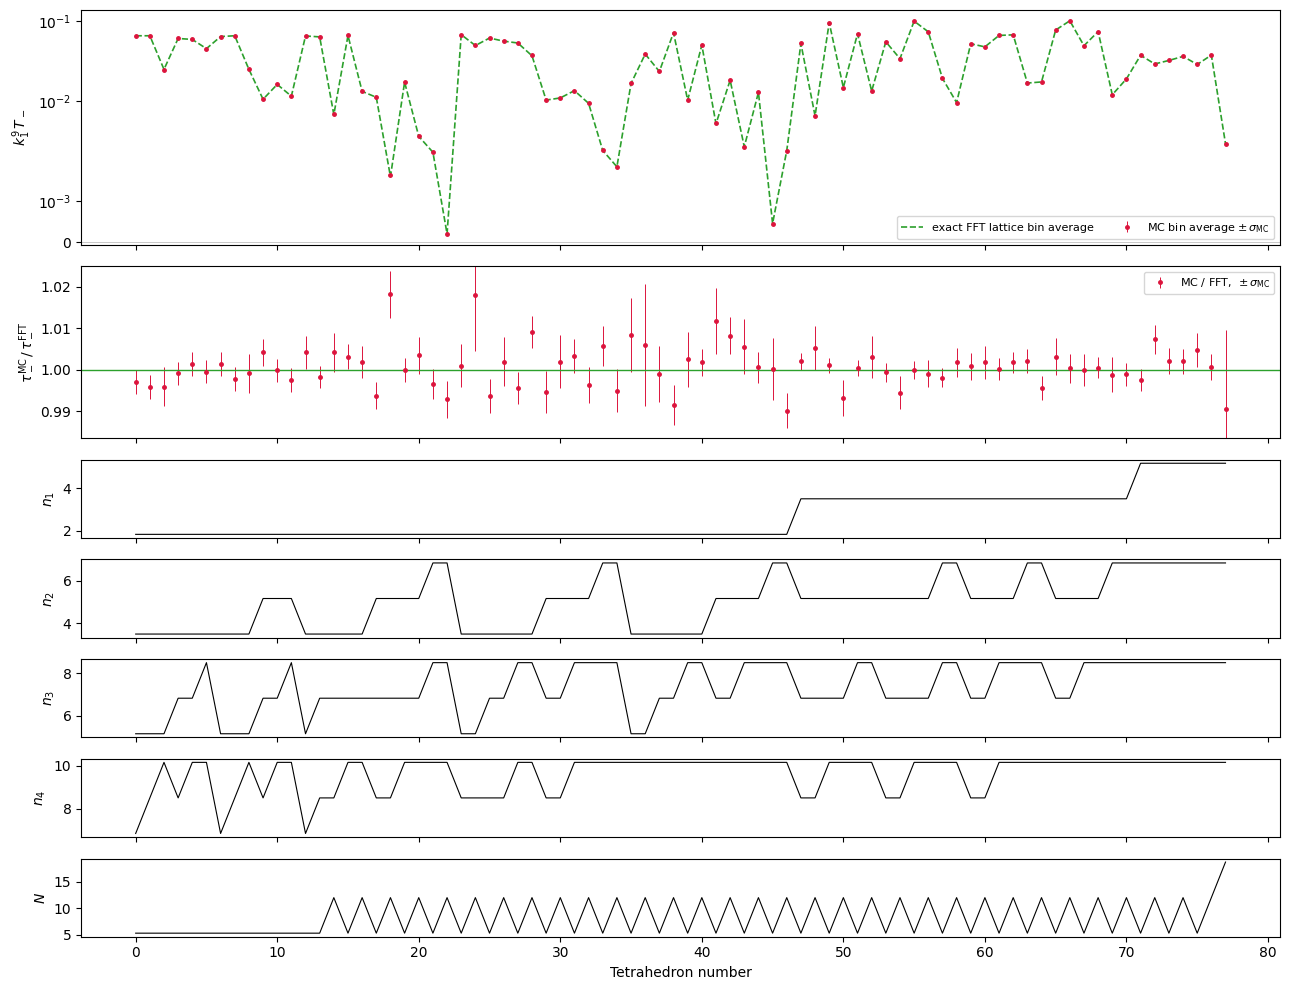

In [30]:
if 'tau_lat' not in globals():
    raise RuntimeError("run the FFT-lattice cell first (tau_lat undefined)")

# Same weight machinery as the figure above; rebuilt only if that cell was not run.
if 'G_rms' not in globals():
    N_scalar = ts_pv._mode_counts(shapes=ts_pv.shapes_odd)
    G_rms = np.sqrt(N_odd/np.where(N_scalar > 0, N_scalar, np.nan))
if 'par' not in globals():
    par = np.array([vparity(s) for s in ts_pv.shapes_odd])[:, None]
if 'kw' not in globals():
    kw = np.sort(np.array([kcen_pv[list(s)] for s in ts_pv.shapes_odd]), axis=1)
if 'w_k1' not in globals():
    w_k1 = (kw[:, 0]**9)[:, None]

# Same cells as the figure above.  mc_ok is required: the MC column only exists there.
sel_r  = good & distinct[:, None] & finite & mc_ok & np.isfinite(tau_lat)
si_r, Bi_r = np.nonzero(sel_r)
ntet_r = np.arange(si_r.size)

T_mc   = par*G_rms*tau_binned
T_mce  = G_rms*np.abs(tau_binned)*tau_mc_rel        # sigma_MC, unsigned
T_ft   = par*G_rms*tau_lat

ym  = (w_k1*T_mc)[si_r, Bi_r]
ye_ = (w_k1*T_mce)[si_r, Bi_r]
yf  = (w_k1*T_ft)[si_r, Bi_r]

# G_rms, the parity sign and k1^9 all cancel in the ratio -> raw tau columns.
r_tt = (tau_binned/np.where(tau_lat != 0, tau_lat, np.nan))[si_r, Bi_r]
r_e  = (np.abs(tau_binned)*tau_mc_rel/np.abs(np.where(tau_lat != 0, tau_lat, np.nan)))[si_r, Bi_r]

print("tetrahedra plotted: %d" % si_r.size)

print("MC / FFT: median %.4f  [16-84%%: %.4f, %.4f]  max|dev| %.3e"
      % (np.nanmedian(r_tt), *np.nanpercentile(r_tt, [16, 84]),
         np.nanmax(np.abs(r_tt - 1))))
_p = (r_tt - 1.0)/r_e
print("pull (MC/FFT - 1)/sigma_MC:  mean %+.2f   rms %.2f   |pull| > 3: %d"
      % (np.nanmean(_p), np.sqrt(np.nanmean(_p**2)), int(np.nansum(np.abs(_p) > 3))))

fig, ax = plt.subplots(7, 1, figsize=(13, 10), sharex=True,
                       gridspec_kw=dict(height_ratios=[3, 2.2, 1, 1, 1, 1, 1]))

ax[0].plot(ntet_r, yf, '--', color='tab:green', lw=1.2,
           label=r'exact FFT lattice bin average')
ax[0].errorbar(ntet_r, ym, yerr=ye_, fmt='o', ms=2.5, lw=0.7, color='crimson',
               label=r'MC bin average $\pm\,\sigma_{\rm MC}$')
_lt = np.nanpercentile(np.abs(np.concatenate([yf, ym])), 5)
ax[0].set_yscale('symlog', linthresh=max(_lt, 1e-300))
ax[0].axhline(0, color='0.7', lw=0.5)
ax[0].set_ylabel(r"$k_1^9\,T_-$")
ax[0].legend(fontsize=8, ncol=2)

ax[1].errorbar(ntet_r, r_tt, yerr=r_e, fmt='o', ms=2.5, lw=0.7, color='crimson',
               label=r'MC / FFT,  $\pm\,\sigma_{\rm MC}$')
ax[1].axhline(1, color='tab:green', lw=1.0)
ax[1].axhline(0, color='0.8', lw=0.5)
# Linear axis: the ratio sits at 1 and a symlog would flatten a per-cent shift.  Cells
# where tau_lat nearly cancels throw the ratio far off; count them instead of rescaling.
_lo, _hi = np.nanpercentile(r_tt, [1, 99])
_pad = 0.25*max(_hi - _lo, 1e-3)
ax[1].set_ylim(_lo - _pad, _hi + _pad)
_off = int(np.nansum((r_tt < _lo - _pad) | (r_tt > _hi + _pad)))
if _off:
    ax[1].set_title("%d/%d cells off scale" % (_off, r_tt.size), fontsize=8, loc='right')
ax[1].set_ylabel(r"$\tau_-^{\rm MC}\,/\,\tau_-^{\rm FFT}$")
ax[1].legend(fontsize=8)

labels = [r"$n_1$", r"$n_2$", r"$n_3$", r"$n_4$", r"$N$"]
cols = [kw[si_r, 0], kw[si_r, 1], kw[si_r, 2], kw[si_r, 3],
        0.5*(diag_pv[:-1] + diag_pv[1:])[Bi_r]]
for a, lab, c in zip(ax[2:], labels, cols):
    a.plot(ntet_r, c/k_f_pv, lw=0.8, color='k')
    a.set_ylabel(lab)
ax[-1].set_xlabel("Tetrahedron number")
fig.tight_layout()


tetrahedra plotted: 78   ordering: N slowest, then n1<n2<n3<n4
cells per diagonal bin: [45 32  1]
ratio panel: 41/78 cells kept   median +1.105   [16-84%: +0.884, +1.559]


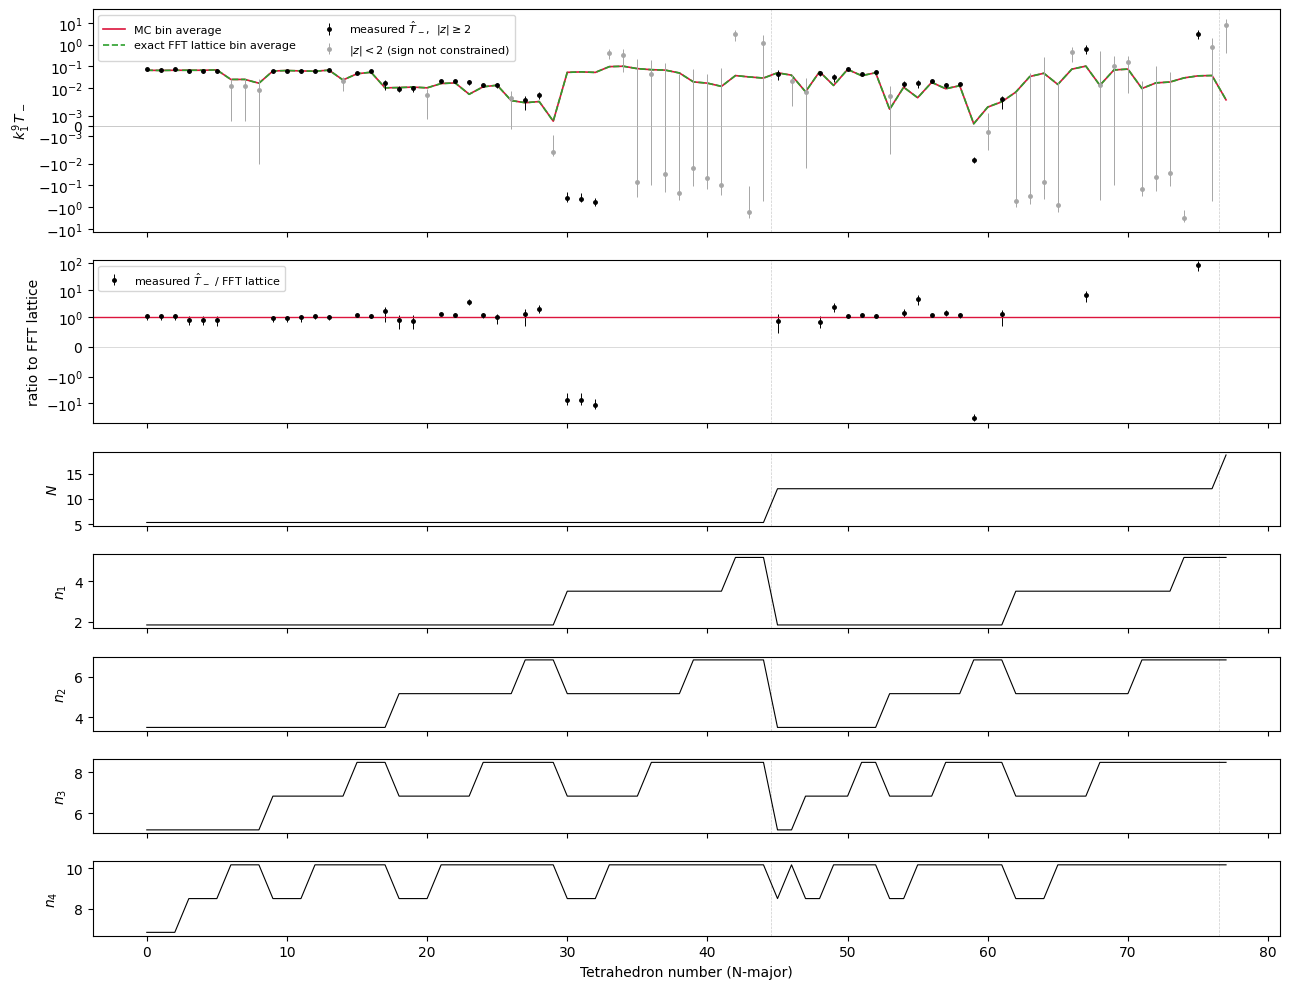

In [31]:
if 'T_meas' not in globals():
    raise RuntimeError("run the measured-vs-binned-theory cell first (T_meas undefined)")

WHICH = 'meas'      # 'meas' -> measurement vs theory (top cell);  'mcfft' -> MC vs FFT

sel_N = sel_p & (np.isfinite(tau_lat) if HAVE_LAT else True)
_si, _Bi = np.nonzero(sel_N)

# lexsort: LAST key is primary.  B first, then n1 < n2 < n3 < n4 inside each diagonal bin.
_srt = np.sort(np.array(ts_pv.shapes_odd), axis=1)
_o   = np.lexsort((_srt[_si, 3], _srt[_si, 2], _srt[_si, 1], _srt[_si, 0], _Bi))
si_N, Bi_N = _si[_o], _Bi[_o]
ntet_N = np.arange(si_N.size)
_edge  = np.flatnonzero(np.diff(Bi_N)) + 0.5          # diagonal-bin boundaries

print("tetrahedra plotted: %d   ordering: N slowest, then n1<n2<n3<n4" % si_N.size)
print("cells per diagonal bin:", np.bincount(Bi_N, minlength=ts_pv.n_diag))

if WHICH == 'meas':
    y0, ye0, lab0 = (w_k1*T_meas)[si_N, Bi_N], (w_k1*T_err)[si_N, Bi_N], r'measured $\hat T_-$'
    yc0, lc0 = (w_k1*T_thy)[si_N, Bi_N], r'MC bin average'
    z0 = (par*tau_hat/tau_err)[si_N, Bi_N]
else:
    y0, ye0 = (w_k1*par*G_rms*tau_binned)[si_N, Bi_N], (w_k1*G_rms*np.abs(tau_binned)*tau_mc_rel)[si_N, Bi_N]
    lab0, yc0, lc0 = r'MC bin average $\pm\,\sigma_{\rm MC}$', None, None
    z0 = np.full(si_N.size, np.inf)                   # every point "significant"
yl0 = (w_k1*T_latt)[si_N, Bi_N] if HAVE_LAT else None
sig_N = np.abs(z0) >= 2

fig, ax = plt.subplots(7, 1, figsize=(13, 10), sharex=True,
                       gridspec_kw=dict(height_ratios=[3, 2.2, 1, 1, 1, 1, 1]))

a = ax[0]
if yc0 is not None:
    a.plot(ntet_N, yc0, '-', color='crimson', lw=1.2, label=lc0)
if HAVE_LAT:
    a.plot(ntet_N, yl0, '--', color='tab:green', lw=1.2, label=r'exact FFT lattice bin average')
a.errorbar(ntet_N[sig_N], y0[sig_N], yerr=ye0[sig_N], fmt='o', ms=2.5, lw=0.7, color='k',
           label=lab0 + (r',  $|z|\geq2$' if WHICH == 'meas' else ''))
if (~sig_N).any():
    a.errorbar(ntet_N[~sig_N], y0[~sig_N], yerr=ye0[~sig_N], fmt='o', ms=2.5, lw=0.7,
               color='0.65', label=r'$|z|<2$ (sign not constrained)')
_stack = [y0] + [v for v in (yc0, yl0) if v is not None]
_lt = np.nanpercentile(np.abs(np.concatenate(_stack)), 5)
a.set_yscale('symlog', linthresh=max(_lt, 1e-300))
a.axhline(0, color='0.7', lw=0.5)
a.set_ylabel(r"$k_1^9\,T_-$")
a.legend(fontsize=8, ncol=2)

# Ratio against the exact FFT column when it exists, else against the MC one.
a = ax[1]
_den, _dlab = (yl0, 'FFT lattice') if HAVE_LAT else (yc0, 'MC theory')
_ok = sig_N & np.isfinite(_den) & (_den != 0)
a.errorbar(ntet_N[_ok], (y0/_den)[_ok], yerr=(ye0/np.abs(_den))[_ok], fmt='o', ms=2.5,
           lw=0.7, color='k', label='%s / %s' % (lab0.split(',')[0], _dlab))
a.axhline(1, color='crimson', lw=1.0)
a.axhline(0, color='0.8', lw=0.5)
a.set_yscale('symlog', linthresh=1.0)
a.set_ylabel(r"ratio to %s" % _dlab)
a.legend(fontsize=8)
print("ratio panel: %d/%d cells kept   median %+.3f   [16-84%%: %+.3f, %+.3f]"
      % (int(_ok.sum()), _ok.size, np.median((y0/_den)[_ok]),
         *np.percentile((y0/_den)[_ok], [16, 84])))

labels = [r"$N$", r"$n_1$", r"$n_2$", r"$n_3$", r"$n_4$"]     # N first: it leads the sort
cols = [0.5*(diag_pv[:-1] + diag_pv[1:])[Bi_N],
        kw[si_N, 0], kw[si_N, 1], kw[si_N, 2], kw[si_N, 3]]
for a, lab, c in zip(ax[2:], labels, cols):
    a.plot(ntet_N, c/k_f_pv, lw=0.8, color='k')
    a.set_ylabel(lab)
for a in ax:
    for x in _edge:
        a.axvline(x, color='0.8', lw=0.5, ls='--', zorder=0)
ax[-1].set_xlabel("Tetrahedron number (N-major)")
fig.tight_layout()
